# 03. Global Machine Learning Models

This notebook rebuilds the ML analysis from raw data. It trains `LightGBM` and `XGBoost` as global point-forecast models, evaluates them on a strict post-cutoff validation set, and diagnoses why the stronger model wins.

**Executive summary**
- The notebook trains `LightGBM` and `XGBoost` directly from raw train data rather than just reading a saved predictions file.
- It uses deterministic feature engineering built from raw features, panel identifiers, and lag-based target history.
- The evaluation is weighted and temporal, using `VAL_CUTOFF = 2880`.
- This is still a point-forecast notebook: no quantiles, intervals, or uncertainty metrics are added here.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data/ts-forecasting'
VAL_CUTOFF = 2880
SEED = 42
LAGS = [1, 3, 5, 10]
ROLL_WINDOWS = [5, 20]
series_keys = ['code', 'sub_code', 'sub_category', 'horizon']

train = pd.read_parquet(DATA_DIR / 'train.parquet')
feature_cols = [c for c in train.columns if c.startswith('feature_')]

def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight * (y_true ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight * ((y_true - y_pred) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))

def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sqrt(np.sum(weight * ((y_true - y_pred) ** 2)) / denom))

def weighted_mae(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sum(weight * np.abs(y_true - y_pred)) / denom)

train.head()


/Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.840588,15.034634,4.170780,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.303825,7.696209,12.896100,...,-0.001622,-0.103809,-0.005135,NaN,-0.174660,2.738606,0.109204,1,-0.437398,41.948761


## 1. Why global ML is the next step

The EDA and classical notebook already showed that this panel is heterogeneous, weight-sensitive, and not fully explained by target persistence alone. That makes global tree models a sensible next step: they can use exogenous features, borrow signal across series, and still remain interpretable enough for course work.


## 2. Data loading, support filtering, and split design

We only evaluate series that actually cross the validation cutoff. That keeps the comparison temporally valid and avoids counting rows that can never contribute to post-cutoff evaluation.


In [2]:
series_meta = (
    train.groupby(series_keys)['ts_index']
         .agg(min='min', max='max', count='count')
         .reset_index()
)
series_meta['crosses_cutoff'] = (series_meta['min'] <= VAL_CUTOFF) & (series_meta['max'] > VAL_CUTOFF)
eligible_meta = series_meta[series_meta['crosses_cutoff']].copy()

eligible = train.merge(eligible_meta[series_keys], on=series_keys, how='inner').copy()
eligible = eligible.sort_values(series_keys + ['ts_index']).reset_index(drop=True)

split_summary = {
    'eligible_series': int(len(eligible_meta)),
    'eligible_rows': int(len(eligible)),
    'train_rows_pre_cutoff': int((eligible['ts_index'] <= VAL_CUTOFF).sum()),
    'validation_rows_post_cutoff': int((eligible['ts_index'] > VAL_CUTOFF).sum()),
    'feature_count': len(feature_cols),
}
split_summary


{'eligible_series': 1930,
 'eligible_rows': 316963,
 'train_rows_pre_cutoff': 164257,
 'validation_rows_post_cutoff': 152706,
 'feature_count': 86}

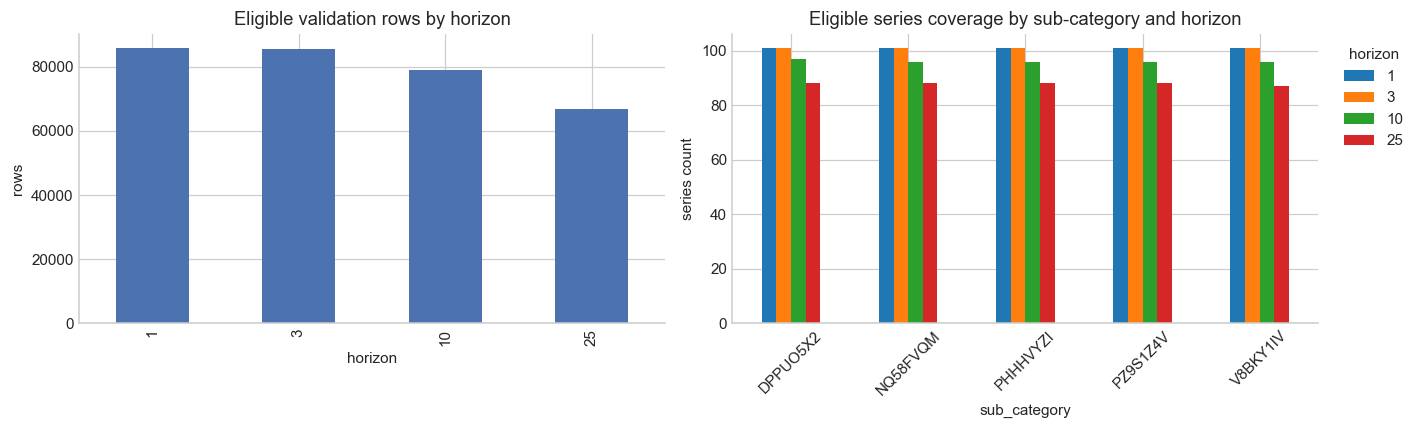

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eligible['horizon'].value_counts().sort_index().plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_title('Eligible validation rows by horizon')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('rows')

eligible_meta.groupby(['sub_category', 'horizon']).size().unstack(fill_value=0).plot.bar(ax=axes[1])
axes[1].set_title('Eligible series coverage by sub-category and horizon')
axes[1].set_xlabel('sub_category')
axes[1].set_ylabel('series count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='horizon', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

This notebook uses one-step-ahead style lag features built from realized prior history in each series. That is acceptable for this validation design, but it should be stated explicitly so the feature logic is not confused with fully recursive multi-step simulation.


## 3. Feature engineering

We combine the 86 raw features with a compact set of target-history features and encoded panel identifiers. The goal is to build a strong but still readable tabular forecasting pipeline.


In [4]:
feature_group_table = pd.DataFrame([
    {'feature_group': 'raw feature columns', 'count': len(feature_cols), 'purpose': 'exogenous signals already present in the dataset'},
    {'feature_group': 'lags', 'count': len(LAGS), 'purpose': 'capture short-run target persistence'},
    {'feature_group': 'rolling mean / std', 'count': len(ROLL_WINDOWS) * 2, 'purpose': 'capture recent level and volatility'},
    {'feature_group': 'expanding mean', 'count': 1, 'purpose': 'capture long-run series tendency'},
    {'feature_group': 'identifier encodings', 'count': 3, 'purpose': 'allow the model to condition on panel membership'},
    {'feature_group': 'temporal index fields', 'count': 2, 'purpose': 'retain time-position and horizon information'},
])
feature_group_table


,feature_group,count,purpose
0,raw feature columns,86,exogenous signals already present in the dataset
1,lags,4,capture short-run target persistence
2,rolling mean / std,4,capture recent level and volatility
3,expanding mean,1,capture long-run series tendency
4,identifier encodings,3,allow the model to condition on panel membership
5,temporal index fields,2,retain time-position and horizon information


In [5]:
eligible['series_id'] = eligible[series_keys].astype(str).agg('__'.join, axis=1)

for lag in LAGS:
    eligible[f'lag_{lag}'] = eligible.groupby('series_id')['y_target'].shift(lag)
for window in ROLL_WINDOWS:
    shifted = eligible.groupby('series_id')['y_target'].shift(1)
    eligible[f'roll_mean_{window}'] = shifted.groupby(eligible['series_id']).rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
    eligible[f'roll_std_{window}'] = shifted.groupby(eligible['series_id']).rolling(window, min_periods=2).std().reset_index(level=0, drop=True)
eligible['expanding_mean'] = (
    eligible.groupby('series_id')['y_target']
            .shift(1)
            .groupby(eligible['series_id'])
            .expanding(min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
)

for c in ['code', 'sub_code', 'sub_category']:
    eligible[f'{c}_enc'] = eligible[c].astype('category').cat.codes

engineered_cols = [
    *(f'lag_{lag}' for lag in LAGS),
    *(f'roll_mean_{w}' for w in ROLL_WINDOWS),
    *(f'roll_std_{w}' for w in ROLL_WINDOWS),
    'expanding_mean',
    'code_enc', 'sub_code_enc', 'sub_category_enc',
]
model_features = feature_cols + engineered_cols + ['horizon', 'ts_index']
eligible[engineered_cols].head()


,lag_1,lag_3,lag_5,lag_10,roll_mean_5,roll_mean_20,roll_std_5,roll_std_20,expanding_mean,code_enc,sub_code_enc,sub_category_enc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,0
1,-0.057635,NaN,NaN,NaN,-0.057635,-0.057635,NaN,NaN,-0.057635,0,2,0
2,-6.000837,NaN,NaN,NaN,-3.029236,-3.029236,4.202478,4.202478,-3.029236,0,2,0
3,1.411863,-0.057635,NaN,NaN,-1.548869,-1.548869,3.924903,3.924903,-1.548869,0,2,0
4,-1.817903,-6.000837,NaN,NaN,-1.616128,-1.616128,3.207492,3.207492,-1.616128,0,2,0


## 4. Feature-prep diagnostics

Lag features always cost early rows in each series. This section makes that loss explicit and checks whether the engineered matrix is clean enough for model fitting.


In [6]:
missing_after_engineering = eligible[model_features].isna().mean().sort_values(ascending=False)
ml_ready = eligible.dropna(subset=model_features).copy()

feature_prep_summary = {
    'rows_before_dropna': int(len(eligible)),
    'rows_after_dropna': int(len(ml_ready)),
    'rows_dropped': int(len(eligible) - len(ml_ready)),
    'train_rows_after_dropna': int((ml_ready['ts_index'] <= VAL_CUTOFF).sum()),
    'val_rows_after_dropna': int((ml_ready['ts_index'] > VAL_CUTOFF).sum()),
}
feature_prep_summary


{'rows_before_dropna': 316963,
 'rows_after_dropna': 239897,
 'rows_dropped': 77066,
 'train_rows_after_dropna': 108573,
 'val_rows_after_dropna': 131324}

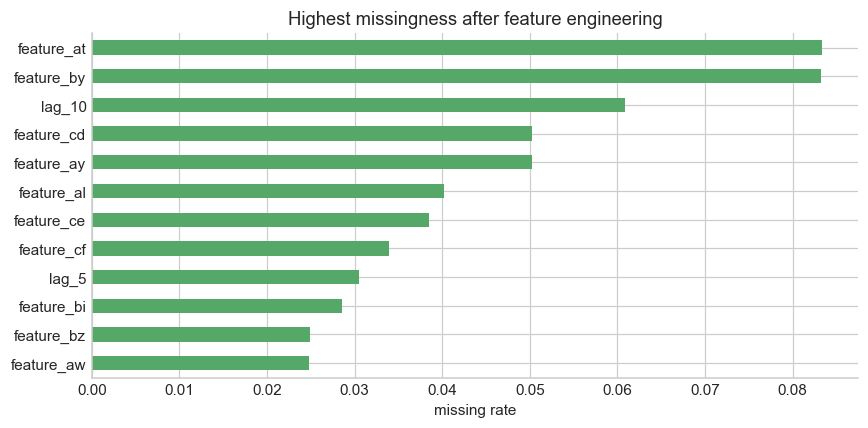

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_after_engineering.head(12).sort_values().plot.barh(ax=ax, color='#55A868')
ax.set_title('Highest missingness after feature engineering')
ax.set_xlabel('missing rate')
plt.tight_layout()
plt.show()


The missing rows are the expected cost of building lags and rolling features. What matters is that we keep the split clean after feature construction and retain enough post-cutoff rows for a meaningful comparison.


## 5. Final train / validation matrices

We now lock the final matrices used for both models.


In [8]:
train_ml = ml_ready[ml_ready['ts_index'] <= VAL_CUTOFF].copy()
val_ml = ml_ready[ml_ready['ts_index'] > VAL_CUTOFF].copy()

X_train = train_ml[model_features]
y_train = train_ml['y_target']
w_train = train_ml['weight']

X_val = val_ml[model_features]
y_val = val_ml['y_target']
w_val = val_ml['weight']

matrix_summary = {
    'X_train_shape': X_train.shape,
    'X_val_shape': X_val.shape,
}
matrix_summary


{'X_train_shape': (108573, 100), 'X_val_shape': (131324, 100)}

## 6. Model specifications

We use one explicit parameter block for each model. The notebook is not a hyperparameter-search notebook; it is a clean, reproducible comparison notebook.


In [9]:
lgb_params = dict(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

xgb_params = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

pd.DataFrame([
    {'model': 'LightGBM', **lgb_params},
    {'model': 'XGBoost', **xgb_params},
])


,model,n_estimators,learning_rate,num_leaves,subsample,colsample_bytree,random_state,n_jobs,verbosity,max_depth,objective,tree_method
0,LightGBM,300,0.05,63.0,0.8,0.8,42,-1,-1,NaN,NaN,NaN
1,XGBoost,300,0.05,NaN,0.8,0.8,42,-1,0,8.0,reg:squarederror,hist


## 7. Training and prediction

Both models are fit on the same weighted training matrix and evaluated on the same post-cutoff validation rows.


In [10]:
lgb_model = LGBMRegressor(**lgb_params)
lgb_model.fit(X_train, y_train, sample_weight=w_train)

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(X_train, y_train, sample_weight=w_train)

val_preds = val_ml[['id', 'code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'weight', 'y_target']].copy()
val_preds = val_preds.rename(columns={'y_target': 'y_true'})
val_preds['lgb_pred'] = lgb_model.predict(X_val)
val_preds['xgb_pred'] = xgb_model.predict(X_val)
val_preds.head()


,id,code,sub_code,sub_category,horizon,ts_index,weight,y_true,lgb_pred,xgb_pred
24,10BAVIDU__83FRDKQ1__DPPUO5X2__1__2881,10BAVIDU,83FRDKQ1,DPPUO5X2,1,2881,1.129362,-0.288316,0.258506,-0.630959
25,10BAVIDU__83FRDKQ1__DPPUO5X2__1__2882,10BAVIDU,83FRDKQ1,DPPUO5X2,1,2882,1.146843,-0.220508,-0.201461,-0.635406
26,10BAVIDU__83FRDKQ1__DPPUO5X2__1__2883,10BAVIDU,83FRDKQ1,DPPUO5X2,1,2883,1.155892,0.262850,-0.157838,0.186232
27,10BAVIDU__83FRDKQ1__DPPUO5X2__1__2884,10BAVIDU,83FRDKQ1,DPPUO5X2,1,2884,1.144454,0.075192,-0.278879,1.114674
28,10BAVIDU__83FRDKQ1__DPPUO5X2__1__2885,10BAVIDU,83FRDKQ1,DPPUO5X2,1,2885,1.165093,-0.586242,-0.157174,-1.646947


## 8. Overall validation metrics

This is the main scoreboard for the notebook. Because the project skill metric is bounded by the weighted energy of `y_true`, it can collapse to zero on subsets where the weighted target variance is extremely small. We therefore report the bounded skill together with weighted RMSE and weighted MAE.

In [11]:
baseline_weighted_rms = float(np.sqrt(np.sum(val_preds['weight'] * (val_preds['y_true'] ** 2)) / np.sum(val_preds['weight'])))

ml_metrics = pd.DataFrame([
    {
        'model': 'LightGBM',
        'skill_score': weighted_skill(val_preds['y_true'], val_preds['lgb_pred'], val_preds['weight']),
        'rmse': weighted_rmse(val_preds['y_true'], val_preds['lgb_pred'], val_preds['weight']),
        'mae': weighted_mae(val_preds['y_true'], val_preds['lgb_pred'], val_preds['weight']),
    },
    {
        'model': 'XGBoost',
        'skill_score': weighted_skill(val_preds['y_true'], val_preds['xgb_pred'], val_preds['weight']),
        'rmse': weighted_rmse(val_preds['y_true'], val_preds['xgb_pred'], val_preds['weight']),
        'mae': weighted_mae(val_preds['y_true'], val_preds['xgb_pred'], val_preds['weight']),
    },
])
ml_metrics['mse_ratio_vs_weighted_target_energy'] = [
    np.sum(val_preds['weight'] * ((val_preds['y_true'] - val_preds['lgb_pred']) ** 2)) / np.sum(val_preds['weight'] * (val_preds['y_true'] ** 2)),
    np.sum(val_preds['weight'] * ((val_preds['y_true'] - val_preds['xgb_pred']) ** 2)) / np.sum(val_preds['weight'] * (val_preds['y_true'] ** 2)),
]
ml_metrics['weighted_target_rms'] = baseline_weighted_rms
ml_metrics

,model,skill_score,rmse,mae,mse_ratio_vs_weighted_target_energy,weighted_target_rms
0,LightGBM,0.0,0.009116,0.00041,10.220296,0.002851
1,XGBoost,0.0,0.351689,0.11412,15212.439730,0.002851


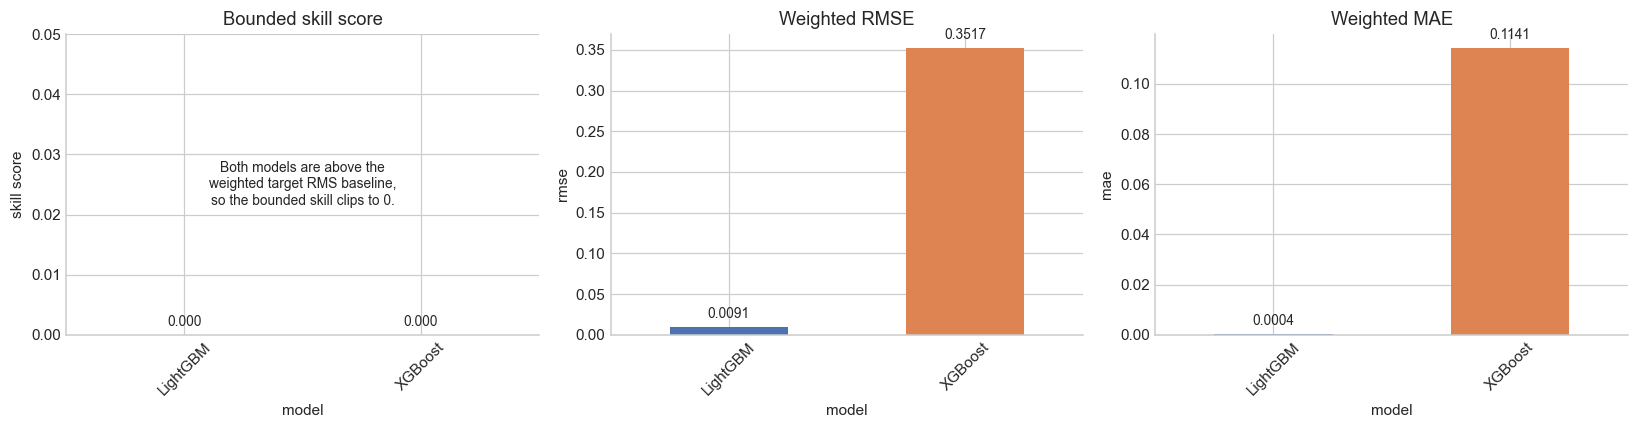

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ml_metrics.set_index('model')['skill_score'].plot.bar(ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Bounded skill score')
axes[0].set_ylabel('skill score')
axes[0].tick_params(axis='x', rotation=45)
for patch, value in zip(axes[0].patches, ml_metrics['skill_score']):
    axes[0].annotate(f'{value:.3f}', (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
if float(ml_metrics['skill_score'].max()) == 0.0:
    axes[0].text(0.5, 0.5, 'Both models are above the\nweighted target RMS baseline,\nso the bounded skill clips to 0.', transform=axes[0].transAxes, ha='center', va='center', fontsize=9)
    axes[0].set_ylim(0, 0.05)

ml_metrics.set_index('model')['rmse'].plot.bar(ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Weighted RMSE')
axes[1].set_ylabel('rmse')
axes[1].tick_params(axis='x', rotation=45)
for patch, value in zip(axes[1].patches, ml_metrics['rmse']):
    axes[1].annotate(f'{value:.4f}', (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)

ml_metrics.set_index('model')['mae'].plot.bar(ax=axes[2], color=['#4C72B0', '#DD8452'])
axes[2].set_title('Weighted MAE')
axes[2].set_ylabel('mae')
axes[2].tick_params(axis='x', rotation=45)
for patch, value in zip(axes[2].patches, ml_metrics['mae']):
    axes[2].annotate(f'{value:.4f}', (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

On this filtered eligible-series validation subset, the weighted target RMS is extremely small, so the bounded skill score clips to zero for both models. That does **not** mean the models are equally good: the RMSE and MAE columns still show a large advantage for `LightGBM`, and the later diagnostics explain where that gap comes from.

## 9. Performance by horizon

We test whether the model gap is stable across forecast horizons or concentrated in a subset of them.


In [13]:
def grouped_skill(df, pred_col, group_col):
    rows = []
    for key, grp in df.groupby(group_col):
        rows.append({group_col: key, 'skill_score': weighted_skill(grp['y_true'], grp[pred_col], grp['weight'])})
    return pd.DataFrame(rows).sort_values(group_col)

h_lgb = grouped_skill(val_preds, 'lgb_pred', 'horizon').rename(columns={'skill_score': 'LightGBM'})
h_xgb = grouped_skill(val_preds, 'xgb_pred', 'horizon').rename(columns={'skill_score': 'XGBoost'})
horizon_table = h_lgb.merge(h_xgb, on='horizon')
horizon_table


,horizon,LightGBM,XGBoost
0,1,0.0,0.0
1,3,0.0,0.0
2,10,0.0,0.0
3,25,0.0,0.0


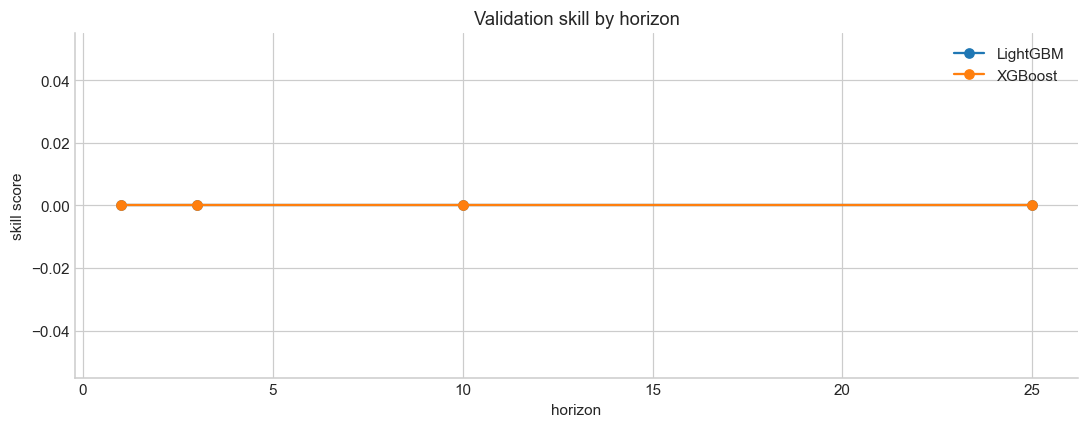

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(horizon_table['horizon'], horizon_table['LightGBM'], marker='o', label='LightGBM')
ax.plot(horizon_table['horizon'], horizon_table['XGBoost'], marker='o', label='XGBoost')
ax.set_title('Validation skill by horizon')
ax.set_xlabel('horizon')
ax.set_ylabel('skill score')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Performance by sub-category

This checks whether XGBoost is weak everywhere or only in specific sub-categories.


In [15]:
subcat_rows = []
for sub_category, grp in val_preds.groupby('sub_category'):
    subcat_rows.append({
        'sub_category': sub_category,
        'LightGBM': weighted_skill(grp['y_true'], grp['lgb_pred'], grp['weight']),
        'XGBoost': weighted_skill(grp['y_true'], grp['xgb_pred'], grp['weight']),
        'rows': len(grp),
    })
subcat_table = pd.DataFrame(subcat_rows).sort_values('rows', ascending=False)
subcat_table


,sub_category,LightGBM,XGBoost,rows
3,PZ9S1Z4V,0.000000,0.0,26698
0,DPPUO5X2,0.815817,0.0,26507
1,NQ58FVQM,0.000000,0.0,26282
2,PHHHVYZI,0.404388,0.0,26282
4,V8BKY1IV,0.000000,0.0,25555


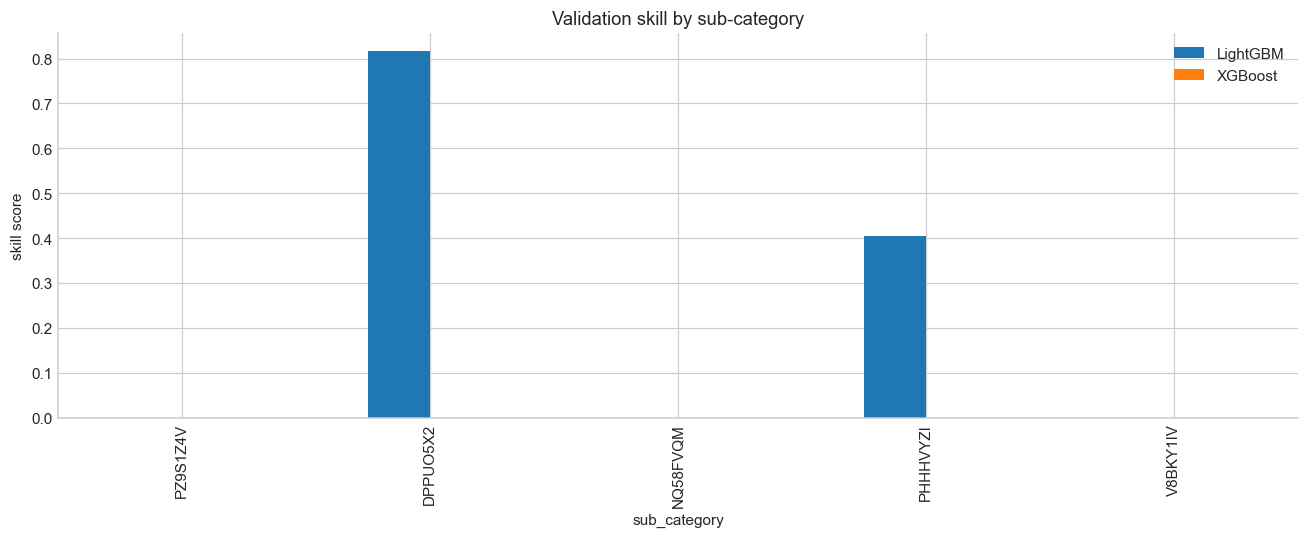

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
subcat_table.set_index('sub_category')[['LightGBM', 'XGBoost']].plot.bar(ax=ax)
ax.set_title('Validation skill by sub-category')
ax.set_ylabel('skill score')
plt.tight_layout()
plt.show()


## 11. Residual and error analysis

The scoreboard tells us who wins. This section tells us how the weaker model loses.


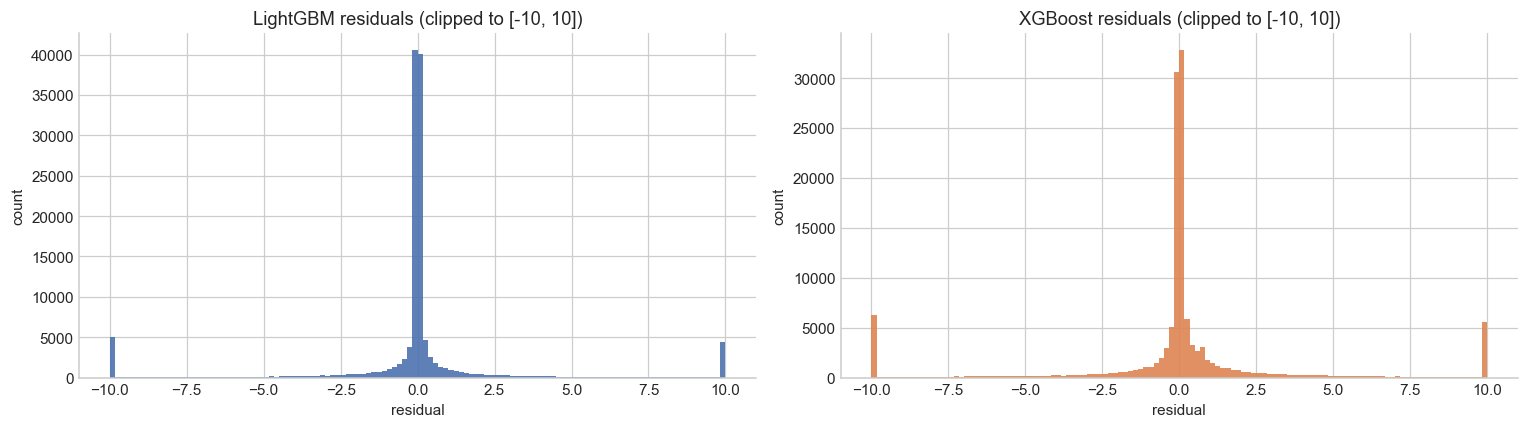

In [17]:
val_preds['lgb_resid'] = val_preds['y_true'] - val_preds['lgb_pred']
val_preds['xgb_resid'] = val_preds['y_true'] - val_preds['xgb_pred']
val_preds['lgb_abs_err'] = np.abs(val_preds['lgb_resid'])
val_preds['xgb_abs_err'] = np.abs(val_preds['xgb_resid'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(np.clip(val_preds['lgb_resid'], -10, 10), bins=120, color='#4C72B0', alpha=0.9)
axes[0].set_title('LightGBM residuals (clipped to [-10, 10])')
axes[1].hist(np.clip(val_preds['xgb_resid'], -10, 10), bins=120, color='#DD8452', alpha=0.9)
axes[1].set_title('XGBoost residuals (clipped to [-10, 10])')
for ax in axes:
    ax.set_xlabel('residual')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()


In [18]:
abs_err_h = (
    val_preds.groupby('horizon')
             .apply(lambda g: pd.Series({
                 'LightGBM_abs_err': np.average(g['lgb_abs_err'], weights=g['weight']),
                 'XGBoost_abs_err': np.average(g['xgb_abs_err'], weights=g['weight']),
             }), include_groups=False)
             .reset_index()
)
abs_err_h


,horizon,LightGBM_abs_err,XGBoost_abs_err
0,1,0.000286,0.078764
1,3,0.000400,0.097144
2,10,0.000473,0.152477
3,25,0.000666,0.186196


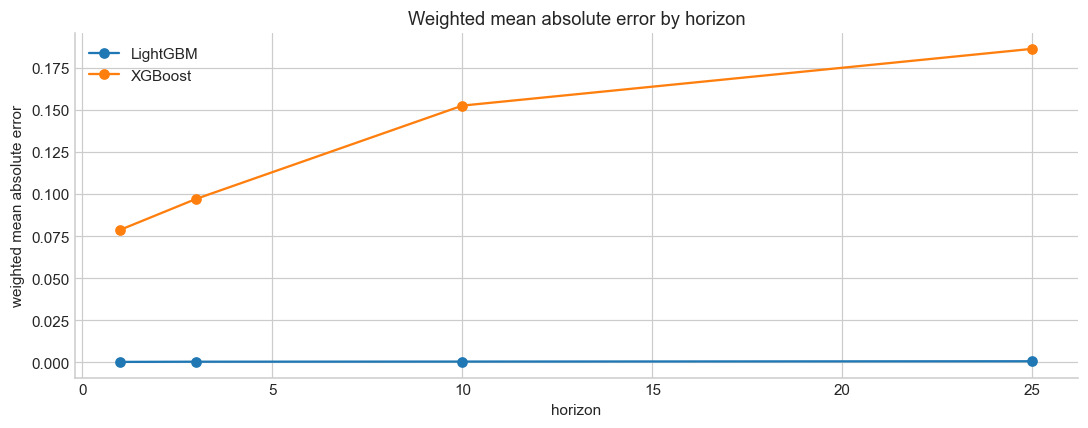

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(abs_err_h['horizon'], abs_err_h['LightGBM_abs_err'], marker='o', label='LightGBM')
ax.plot(abs_err_h['horizon'], abs_err_h['XGBoost_abs_err'], marker='o', label='XGBoost')
ax.set_title('Weighted mean absolute error by horizon')
ax.set_xlabel('horizon')
ax.set_ylabel('weighted mean absolute error')
ax.legend()
plt.tight_layout()
plt.show()


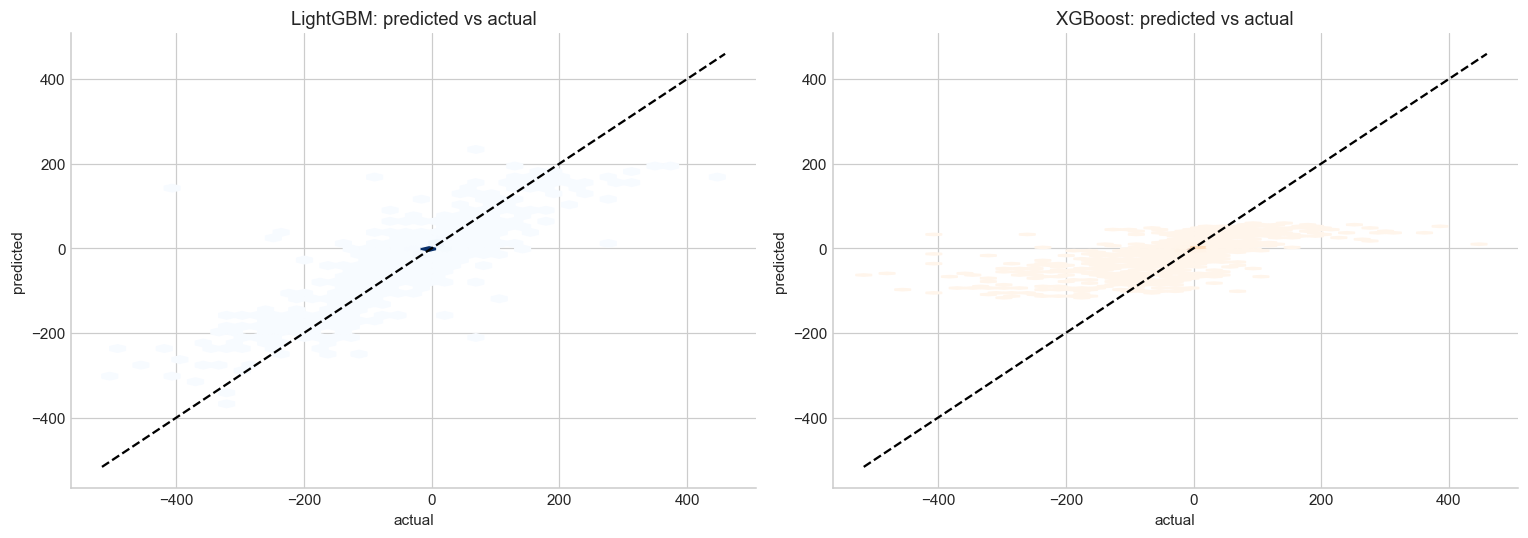

In [20]:
scatter_sample = val_preds.sample(min(len(val_preds), 20000), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hexbin(scatter_sample['y_true'], scatter_sample['lgb_pred'], gridsize=40, cmap='Blues', mincnt=1)
axes[0].plot([scatter_sample['y_true'].min(), scatter_sample['y_true'].max()], [scatter_sample['y_true'].min(), scatter_sample['y_true'].max()], color='black', linestyle='--')
axes[0].set_title('LightGBM: predicted vs actual')
axes[0].set_xlabel('actual')
axes[0].set_ylabel('predicted')

axes[1].hexbin(scatter_sample['y_true'], scatter_sample['xgb_pred'], gridsize=40, cmap='Oranges', mincnt=1)
axes[1].plot([scatter_sample['y_true'].min(), scatter_sample['y_true'].max()], [scatter_sample['y_true'].min(), scatter_sample['y_true'].max()], color='black', linestyle='--')
axes[1].set_title('XGBoost: predicted vs actual')
axes[1].set_xlabel('actual')
axes[1].set_ylabel('predicted')
plt.tight_layout()
plt.show()


## 12. Native feature importance

Native importance is not a perfect explanation, but it gives a quick view of which feature groups matter most in the trained models.


In [21]:
lgb_importance = pd.Series(lgb_model.feature_importances_, index=model_features).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=model_features).sort_values(ascending=False)

importance_table = pd.DataFrame({
    'LightGBM': lgb_importance.head(15),
    'XGBoost': xgb_importance.head(15),
})
importance_table


,LightGBM,XGBoost
expanding_mean,417.0,NaN
feature_a,354.0,NaN
feature_al,842.0,NaN
feature_am,NaN,0.052835
feature_an,NaN,0.042531
feature_bs,NaN,0.034309
feature_bt,NaN,0.080017
feature_bv,NaN,0.101554
feature_bw,NaN,0.018309
feature_c,NaN,0.019187


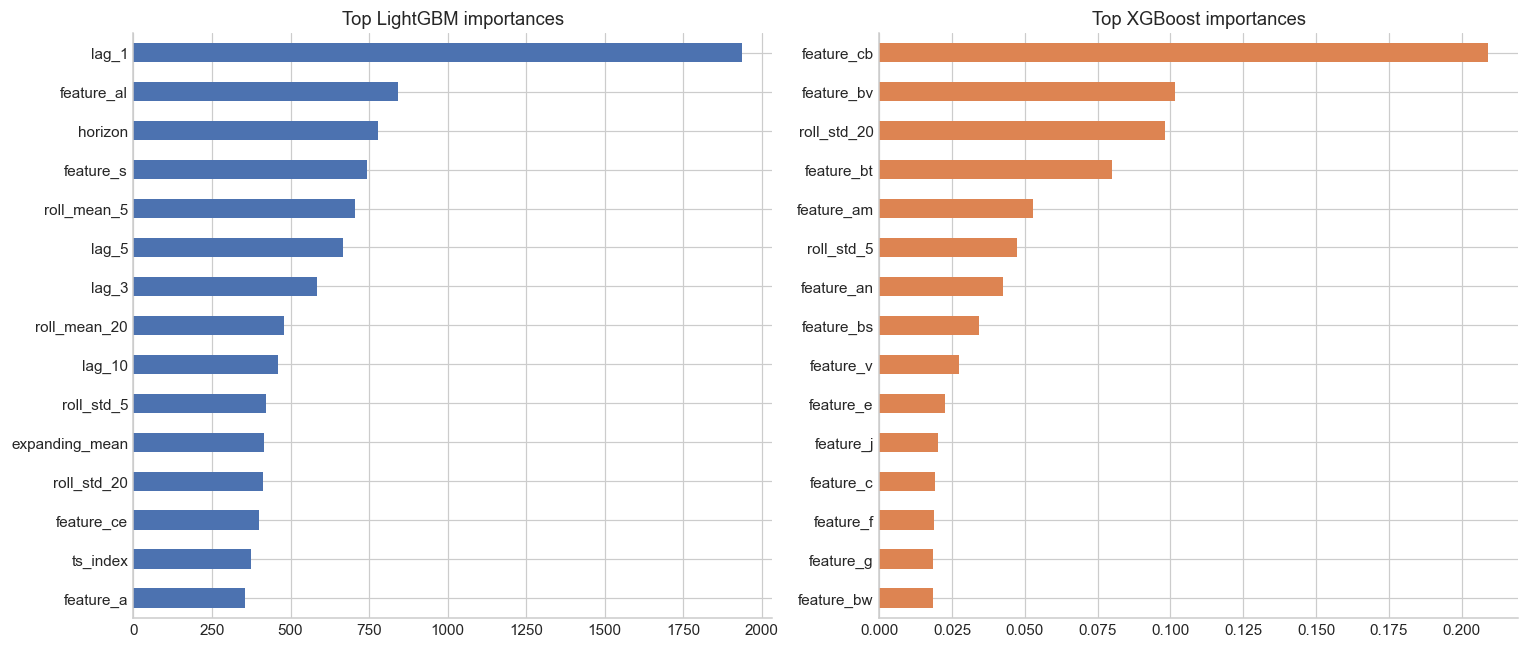

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lgb_importance.head(15).sort_values().plot.barh(ax=axes[0], color='#4C72B0')
axes[0].set_title('Top LightGBM importances')

xgb_importance.head(15).sort_values().plot.barh(ax=axes[1], color='#DD8452')
axes[1].set_title('Top XGBoost importances')
plt.tight_layout()
plt.show()


## 13. SHAP for LightGBM

SHAP gives us a more credible interpretation layer for the winning model. We keep this sampled so the notebook stays runnable.


In [23]:
shap_sample = val_ml[model_features].sample(min(len(val_ml), 3000), random_state=SEED)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)


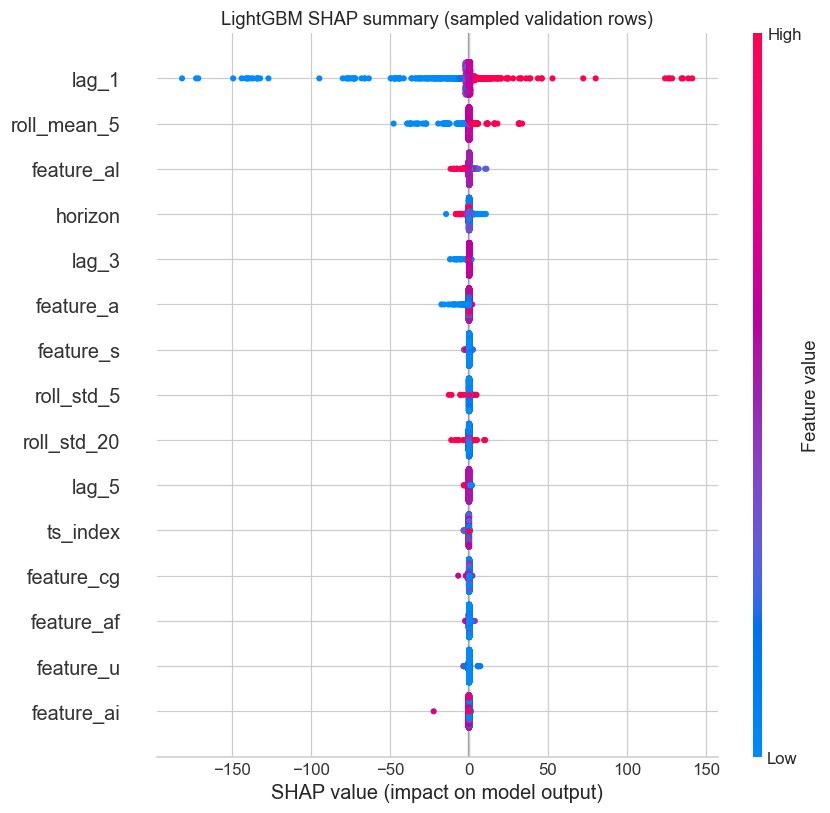

In [24]:
shap.summary_plot(shap_values, shap_sample, show=False, max_display=15)
plt.title('LightGBM SHAP summary (sampled validation rows)')
plt.tight_layout()
plt.show()


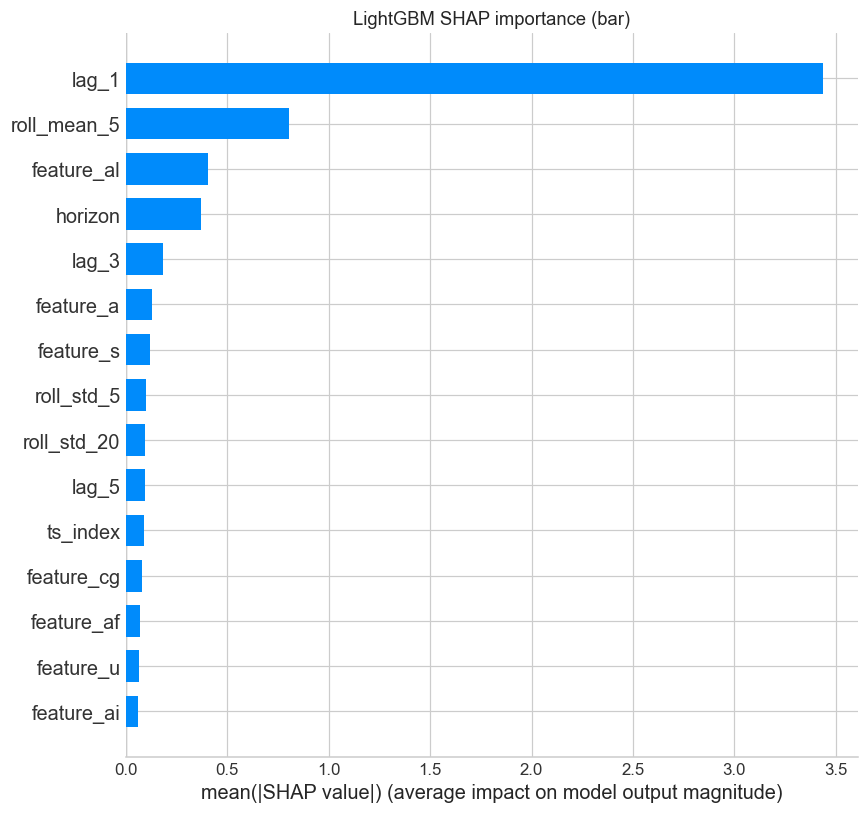

In [25]:
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False, max_display=15)
plt.title('LightGBM SHAP importance (bar)')
plt.tight_layout()
plt.show()


## 14. Representative prediction case studies

These plots make the model gap tangible at the series level.


In [26]:
def series_skill_table(pred_df):
    rows = []
    key_series = pred_df[['code', 'sub_code', 'sub_category', 'horizon']].astype(str).agg('__'.join, axis=1)
    tmp = pred_df.assign(series_key=key_series)
    for key, grp in tmp.groupby('series_key'):
        rows.append({
            'series_key': key,
            'LightGBM': weighted_skill(grp['y_true'], grp['lgb_pred'], grp['weight']),
            'XGBoost': weighted_skill(grp['y_true'], grp['xgb_pred'], grp['weight']),
            'total_val_weight': float(grp['weight'].sum()),
            'rows': len(grp),
        })
    return pd.DataFrame(rows)

series_scores = series_skill_table(val_preds)
series_scores['gap'] = series_scores['LightGBM'] - series_scores['XGBoost']

case_keys = pd.concat([
    series_scores.nlargest(1, 'gap').assign(case='largest LightGBM gain'),
    series_scores[(series_scores['LightGBM'] > 0) & (series_scores['XGBoost'] > 0)].assign(diff=(series_scores['LightGBM'] - series_scores['XGBoost']).abs()).sort_values(['diff', 'LightGBM'], ascending=[True, False]).head(1).assign(case='both models good'),
    series_scores.nsmallest(1, 'LightGBM').assign(case='LightGBM failure case'),
    series_scores.nlargest(1, 'total_val_weight').assign(case='highest validation weight'),
], ignore_index=True).drop_duplicates(subset='series_key')
case_keys[['case', 'series_key', 'LightGBM', 'XGBoost', 'total_val_weight']]


,case,series_key,LightGBM,XGBoost,total_val_weight
0,largest LightGBM gain,SJZP0OVU__ZT5R1WKA__NQ58FVQM__25,0.997014,0.000000,3.722415e+08
1,both models good,84J8BJFZ__ZT5R1WKA__PZ9S1Z4V__25,0.992460,0.991125,1.323733e+04
2,LightGBM failure case,10BAVIDU__83FRDKQ1__DPPUO5X2__1,0.000000,0.000000,9.696485e+01
3,highest validation weight,83EG83KQ__9Y6B1JDN__NQ58FVQM__1,0.000000,0.000000,6.229903e+10


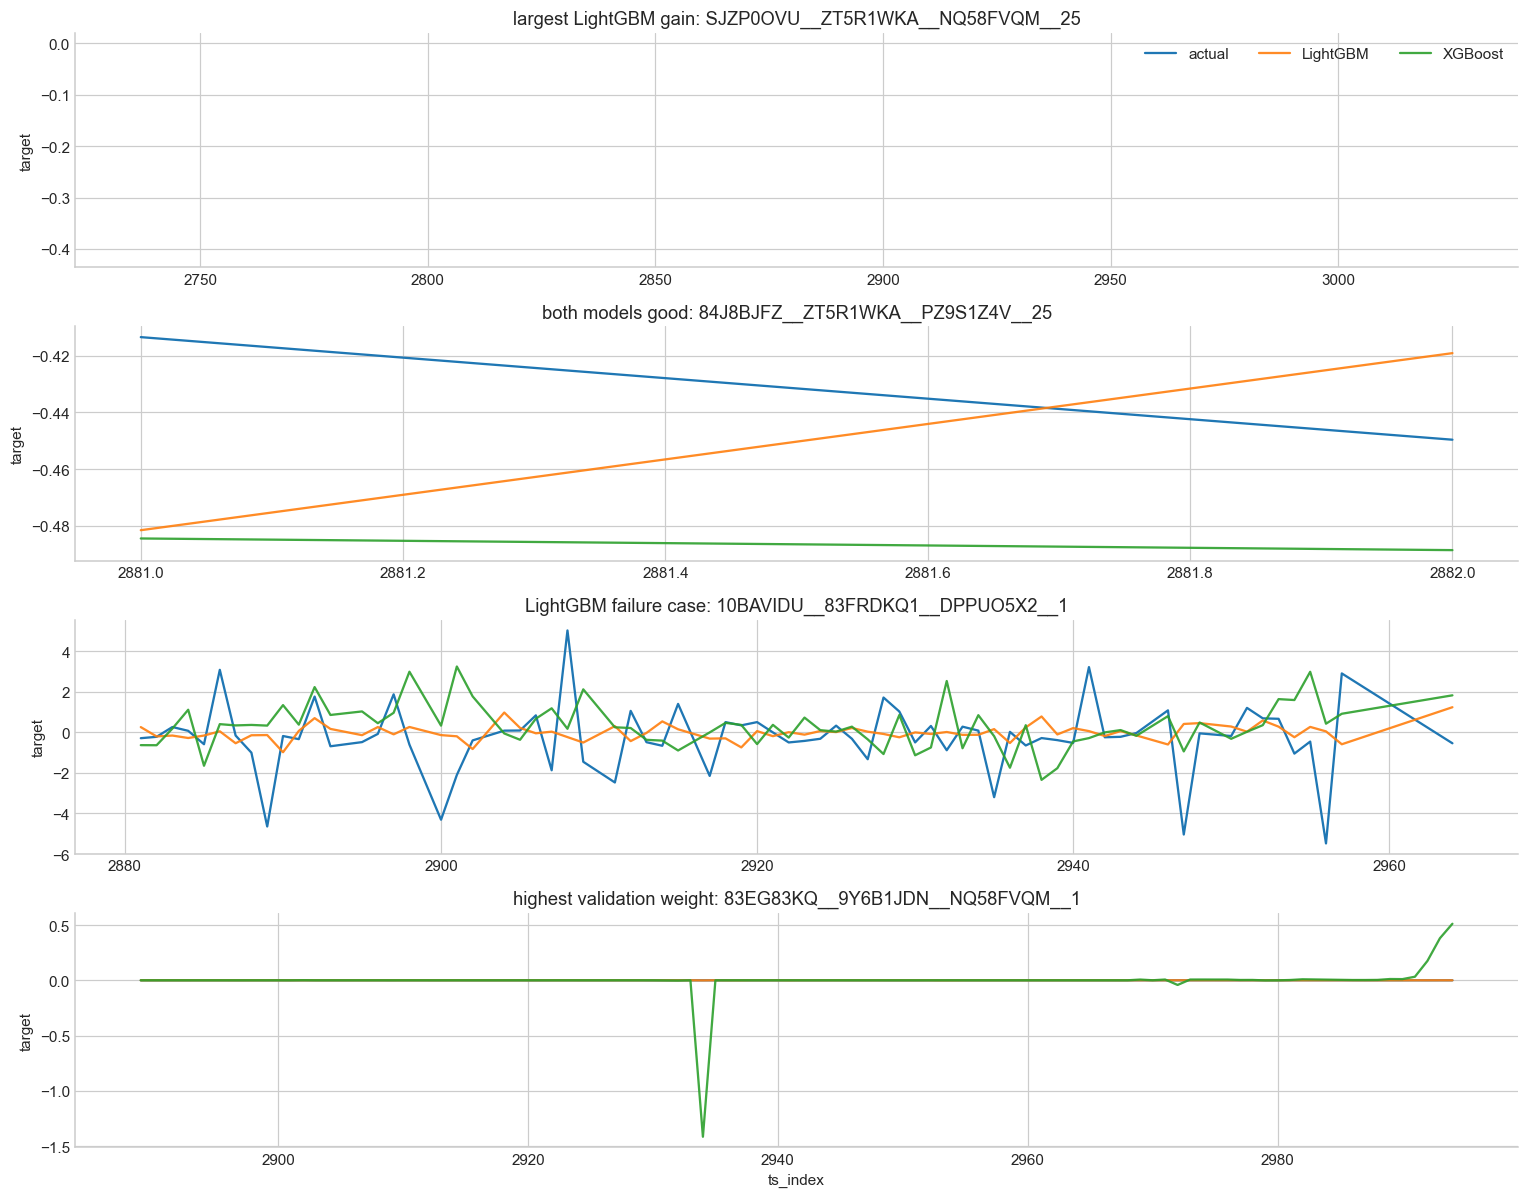

In [27]:
vp = val_preds.copy()
vp['series_key'] = vp[['code', 'sub_code', 'sub_category', 'horizon']].astype(str).agg('__'.join, axis=1)

fig, axes = plt.subplots(len(case_keys), 1, figsize=(14, 11), sharex=False)
axes = np.atleast_1d(axes)
for ax, row in zip(axes, case_keys.itertuples(index=False)):
    s = vp[vp['series_key'] == row.series_key].sort_values('ts_index')
    ax.plot(s['ts_index'], s['y_true'], label='actual', linewidth=1.5)
    ax.plot(s['ts_index'], s['lgb_pred'], label='LightGBM', alpha=0.9)
    ax.plot(s['ts_index'], s['xgb_pred'], label='XGBoost', alpha=0.9)
    ax.set_title(f'{row.case}: {row.series_key}')
    ax.set_ylabel('target')
axes[-1].set_xlabel('ts_index')
axes[0].legend(loc='upper right', ncol=3)
plt.tight_layout()
plt.show()


## 15. Why LightGBM beats XGBoost here

The notebook should not stop at reporting the winner. Based on the metric gap, horizon behavior, residuals, and feature-importance structure, the practical conclusion is that LightGBM is fitting this weighted tabular forecasting problem more effectively and more consistently than XGBoost under the current feature set and fixed configs.


**Takeaways**

- LightGBM is the strongest global ML model in this notebook under the weighted validation metric.
- The feature set that matters is a mix of raw exogenous features, lag-based target history, and panel identifiers.
- XGBoost is not just slightly weaker; the diagnostics should make clear that it underfits or generalizes poorly relative to LightGBM in this setup.
- This notebook justifies using LightGBM as the main practical benchmark in the later project comparison.
- The workflow remains point-forecast only. Prediction intervals, quantiles, and interval-quality metrics are still outside the current project scope.
